<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [3]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 128.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 150.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 113.8 MB/s eta 0:00:00


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [4]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


<StringArray>
[                                         nan,
                                 'Healthcare',
                       'Software Development',
                 'Banking/Financial Services',
                                     'Other:',
               'Media & Advertising Services',
                                  'Insurance',
 'Internet, Telecomm or Information Services',
                           'Higher Education',
                                     'Energy',
                                    'Fintech',
               'Retail and Consumer Services',
                              'Manufacturing',
                                 'Government',
       'Computer Systems Design and Services',
            'Transportation, or Supply Chain']
Length: 16, dtype: str
Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services    

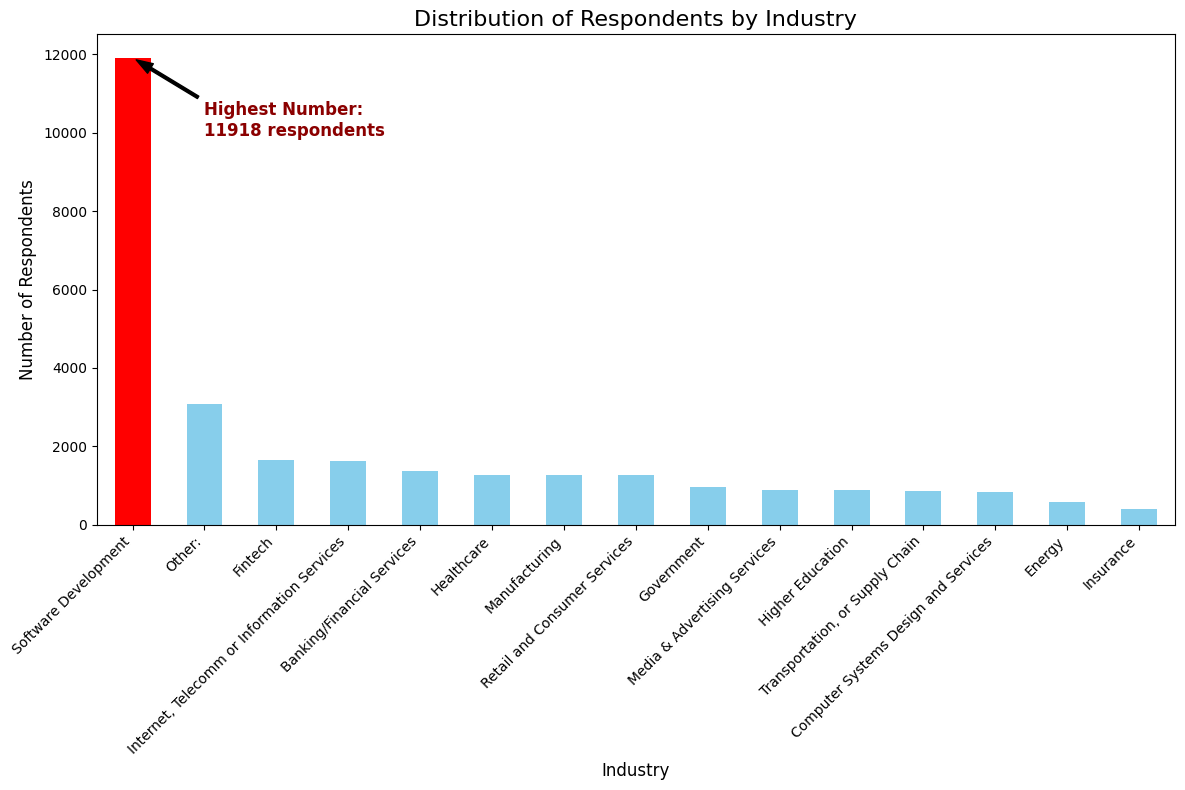

In [5]:
##Write your code here

#Let's see where industries look like they will be reported
print(df['Industry'].unique())

#find count of industries 
industry_counts = df['Industry'].value_counts()
print(industry_counts)

# Define your target category and colors to highlight one bar
target = 'Software Development'  # Change this to the bar you want to highlight
colors = ['red' if x == target else 'skyblue' for x in industry_counts.index]

#make the bar chart
ax = industry_counts.plot(kind='bar', color= colors, stacked=True, figsize=(12, 8))

# Automatically find the largest bar's value and its name
max_val = industry_counts.max()
max_idx = industry_counts.idxmax() # The name of the largest industry
max_pos = list(industry_counts.index).index(max_idx) # Its position on the x-axis

# Add the annotation (The "Pointer")
ax.annotate(f'Highest Number:\n{max_val} respondents', 
            xy=(max_pos, max_val),            # Pointing to (x, y)
            xytext=(max_pos + 1, max_val-2000),    # Where the text starts (slightly down and to the right)
            fontsize=12, 
            fontweight='bold',
            color='darkred',
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8))


#Add titles and labels for clarity
plt.title('Distribution of Respondents by Industry', fontsize=16)
plt.xlabel('Industry', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)

#Move the legend outside the plot so it doesn't cover the data
#plt.legend(title='Industry', bbox_to_anchor=(1.11, 1), loc='upper right')

plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()


<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [6]:
##Write your code here

#calculate mean, median and standard deviation for ConvertedCompYearly
comp_mean = df['ConvertedCompYearly'].mean()
comp_median = df['ConvertedCompYearly'].median()
comp_std = df['ConvertedCompYearly'].std()

print(f'Yearly comp mean, median, and std are {comp_mean}, {comp_median}, and {comp_std}, respectivley')

#Identify compensation values exceeding defined threshold (3 std above mean)
threshold = comp_mean + (3 * comp_std)

#filter df for rows exceeding the threshold
outliers = df[df['ConvertedCompYearly'] > threshold]

#print outliers
print(f'The threshold for high outliers is {threshold}')
print(f'Number of respondents that have outlier compensation: {len(outliers)} out of {len(df)}')





Yearly comp mean, median, and std are 86155.28726264134, 65000.0, and 186756.97308629757, respectivley
The threshold for high outliers is 646426.2065215341
Number of respondents that have outlier compensation: 89 out of 65437


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Yearly comp 25th percentile is 32712.0, and 75th percentile is 107971.5
Yearly comp 25th Interquartile Range is 75259.5
Any compensation above $220860.75 or below $-80177.25 is a statistical outlier
The threshold for high outliers is 220860.75 and there are 978 upper outliers
The threshold for low outliers is -80177.25 and there are 0 lower outliers


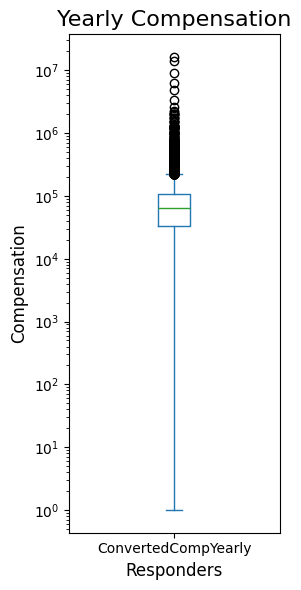

In [7]:
##Write your code here
#calculate first (25%) and third (75%) quartiles for ConvertedCompYearly
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
print(f'Yearly comp 25th percentile is {Q1}, and 75th percentile is {Q3}')

#calculate Interquartile Range (IQR) for ConvertedCompYearly
IQR = Q3-Q1
print(f'Yearly comp 25th Interquartile Range is {IQR}')

#Determine upper and lower bounds for outliers
#Tukey's Fences outlier is any value 1.5 times the IQR above Q3 or below Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Any compensation above ${upper_bound} or below ${lower_bound} is a statistical outlier')

#filter df for rows above upper or below lower bounds for outliers
upper_outliers = df[df['ConvertedCompYearly'] > upper_bound]
lower_outliers = df[df['ConvertedCompYearly'] < lower_bound]

#print outliers
print(f'The threshold for high outliers is {upper_bound} and there are {len(upper_outliers)} upper outliers')
print(f'The threshold for low outliers is {lower_bound} and there are {len(lower_outliers)} lower outliers')


#make the box plot chart
ax = df['ConvertedCompYearly'].plot(kind='box', figsize=(3, 6))
# Set the Y-axis to a log scale
ax.set_yscale('log')
fmt = '${x:,.0f}'

#Add titles and labels for clarity
plt.title('Yearly Compensation', fontsize=16)
plt.xlabel('Responders', fontsize=12)
plt.ylabel('Compensation', fontsize=12)

plt.tight_layout()
plt.show()




<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [8]:
##Write your code here

#First need to remove nan's from ConvertedCompYearly column
!pip install numpy
import numpy as np
df = df.dropna(subset=['ConvertedCompYearly'])

#make a new dataframe by filtering, keeping only rows that fall within upper and lower bounds
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & 
                    (df['ConvertedCompYearly'] <= upper_bound)]

#Validate size of new DataFrame
original_size = len(df)
new_size = len(df_no_outliers)
outliers_removed = original_size - new_size
             

#print results
print(f'The threshold for high outliers is {upper_bound} and there are {len(upper_outliers)} upper outliers')
print(f'The threshold for low outliers is {lower_bound} and there are {len(lower_outliers)} lower outliers')
print(f'The original length of the data frame was {original_size} and there were {outliers_removed} outliers removed, making the updated dataframe with {new_size} data points')




The threshold for high outliers is 220860.75 and there are 978 upper outliers
The threshold for low outliers is -80177.25 and there are 0 lower outliers
The original length of the data frame was 23435 and there were 978 outliers removed, making the updated dataframe with 22457 data points


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


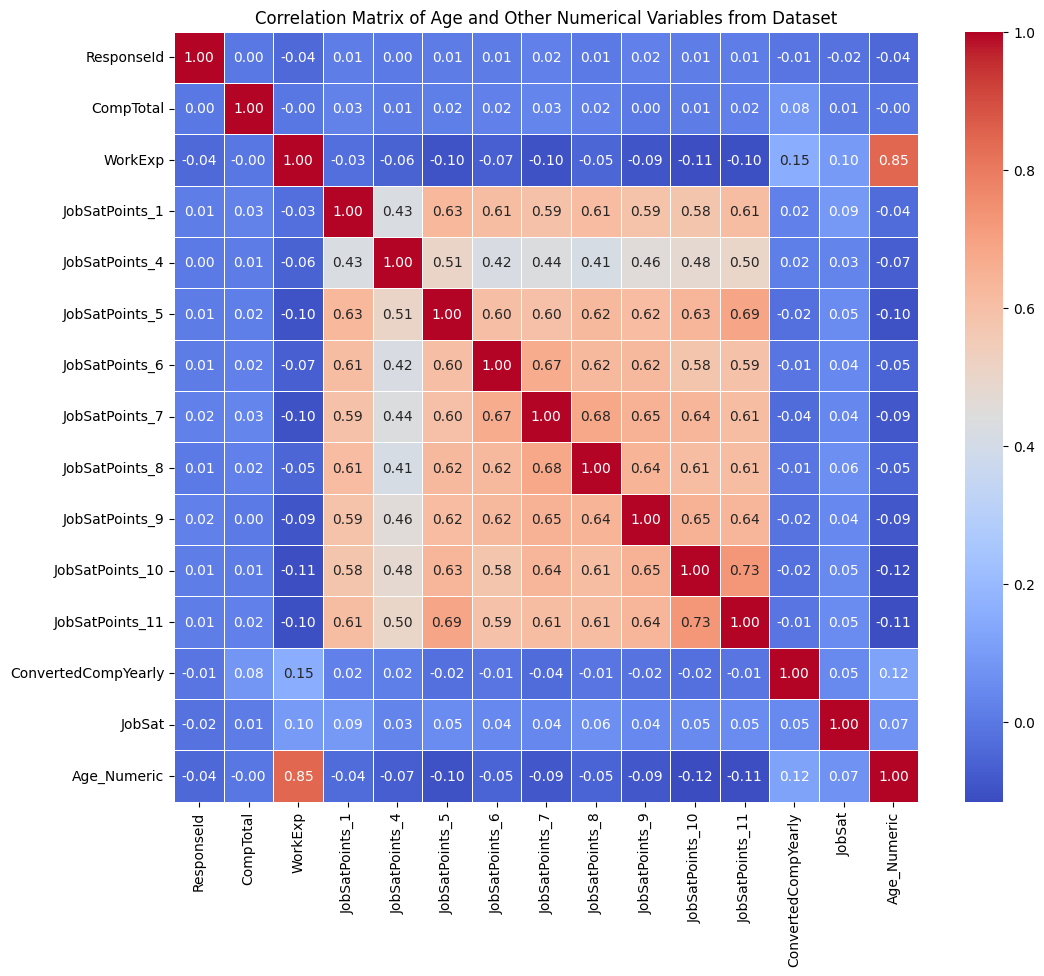

In [12]:
##Write your code here

#df['Age'].unique() #used to see the unique values, can uncomment when needed

#Define the mapping based on 'Age' answers
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 66,
    'Prefer not to say': np.nan
}

# Apply the mapping to create a new numeric column
df['Age_Numeric'] = df['Age'].map(age_mapping)

# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

#plot a heatmap of 'Age' vs other numeric columns
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Age and Other Numerical Variables from Dataset')
plt.show()


<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
